# Rotten Tomatoes Movie Review Sentiment Analysis Using LSTM Networks

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Load Dataset

In [2]:
df = pd.read_csv("/content/rotten_tomatoes_movie_reviews.csv")

print(df.shape)
df.head()

(80846, 11)


,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),Timed to be just long enough for most youngste...,POSITIVE,http://www.deseretnews.com/article/700003233/B...
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,It doesn't matter if a movie costs 300 million...,NEGATIVE,http://www.dreadcentral.com/index.php?name=Rev...
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,The choreography is so precise and lifelike at...,POSITIVE,https://www.cbr.com/city-hunter-shinjuku-priva...
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may ...,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/0...
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and some...,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerou...


# Feature Selection

In [3]:
df = df[['reviewText', 'scoreSentiment']]

df.dropna(inplace=True)

print(df.shape)
df.head()

(76783, 2)


,reviewText,scoreSentiment
0,Timed to be just long enough for most youngste...,POSITIVE
1,It doesn't matter if a movie costs 300 million...,NEGATIVE
2,The choreography is so precise and lifelike at...,POSITIVE
3,The film's out-of-touch attempts at humor may ...,NEGATIVE
4,Its clumsy determination is endearing and some...,POSITIVE


#  Sentiment Filtering

In [4]:
df = df[
    (df['scoreSentiment'] == 'POSITIVE') |
    (df['scoreSentiment'] == 'NEGATIVE')
]

print(df['scoreSentiment'].value_counts())

scoreSentiment
POSITIVE    51610
NEGATIVE    25173
Name: count, dtype: int64


# Data Shuffling

In [8]:
df = df.sample(n=df.shape[0], random_state=42)

print(df.shape)

(76783, 2)


# Label Encoding

In [7]:
df['scoreSentiment'] = df['scoreSentiment'].map({
    'POSITIVE': 1,
    'NEGATIVE': 0
})

texts = df['reviewText']
labels = df['scoreSentiment']

# Text Preprocessing

In [9]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

texts = texts.apply(clean_text)

# Tokenization

In [10]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# Sequence Padding

In [11]:
maxlen = 200

X = pad_sequences(
    sequences,
    maxlen=maxlen
)

y = labels

# Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build the LSTM Model

In [13]:
model = Sequential()

model.add(
    Embedding(
        vocab_size,
        128,
        input_length=maxlen
    )
)

model.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Compile the Model

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - accuracy: 0.7620 - loss: 0.4917 - val_accuracy: 0.7999 - val_loss: 0.4197
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 463s 1s/step - accuracy: 0.8398 - loss: 0.3629 - val_accuracy: 0.8087 - val_loss: 0.4118
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.8633 - loss: 0.3098 - val_accuracy: 0.8091 - val_loss: 0.4799
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.8868 - loss: 0.2586 - val_accuracy: 0.8034 - val_loss: 0.4786
Epoch 5/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 465s 1s/step - accuracy: 0.9059 - loss: 0.2176 - val_accuracy: 0.7961 - val_loss: 0.5415


# Model Evaluation

In [16]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss:", loss)
print("Accuracy:", accuracy)

480/480 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.8064 - loss: 0.5052
Loss: 0.5051531791687012
Accuracy: 0.8064075112342834


# Accuracy Visualization

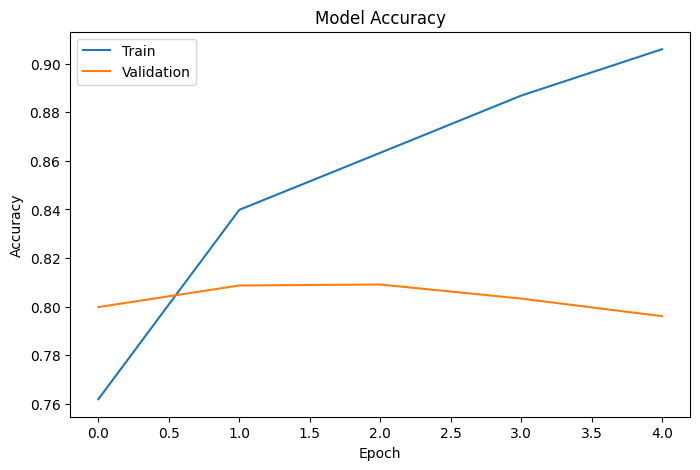

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# Loss Visualization

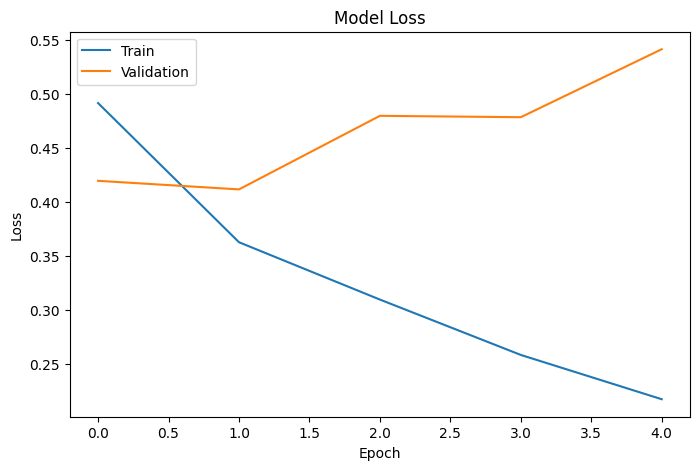

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

#  Classification Report

In [20]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(
    classification_report(
        y_test,
        y_pred
    )
)

480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step
              precision    recall  f1-score   support

           0       0.72      0.65      0.68      4954
           1       0.84      0.88      0.86     10403

    accuracy                           0.81     15357
   macro avg       0.78      0.77      0.77     15357
weighted avg       0.80      0.81      0.80     15357



#  Review Prediction

In [21]:
sample_text = [
    "This movie was absolutely amazing and fantastic"
]

sample_seq = tokenizer.texts_to_sequences(sample_text)

sample_pad = pad_sequences(
    sample_seq,
    maxlen=maxlen
)

prediction = model.predict(sample_pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.99939203]]


#  Prediction Result

In [22]:
if prediction[0][0] > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😔")

Positive Review 😊
